# Data & Backend Walkthrough

This notebook shows **how the credit scoring system actually works**, end to end:

1. **The data** — the Home Credit Default Risk dataset (307,511 loan applications)
2. **The features** — the eight applicant-facing features the product collects
3. **The model** — how XGBoost + SMOTE + the calibrated decision threshold behave
4. **The backend** — a live demo of the FastAPI service running in Docker

Every chart is generated from the real training data, and the backend section calls
the **running API container** — the same one serving the dashboard at
`localhost:8501`.

## 0. Setup

If the API is not running, start it first: `docker compose up -d` (or locally:
`uvicorn src.app:app --port 8000`).

In [1]:
%matplotlib inline

import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import requests

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

REPO = Path.cwd()
sys.path.insert(0, str(REPO))  # allow `import src.*` from the repo root

DATA_PATH = REPO / "data" / "application_train.csv"
TARGET = "TARGET"

print(f"pandas {pd.__version__} | dataset present: {DATA_PATH.exists()}")

pandas 3.0.6 | dataset present: True


## 1. The data

Each row is one loan application. `TARGET = 1` means the client **defaulted**
(payment difficulties: late >90 days on at least one instalment). The dataset is
famously imbalanced — that shapes every modeling decision downstream.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df[[TARGET, "SK_ID_CURR", "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "EXT_SOURCE_3"]].head()

Rows: 307,511 | Columns: 122


,TARGET,SK_ID_CURR,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,EXT_SOURCE_3
0,1,100002,202500.0,406597.5,24700.5,0.139376
1,0,100003,270000.0,1293502.5,35698.5,NaN
2,0,100004,67500.0,135000.0,6750.0,0.729567
3,0,100006,135000.0,312682.5,29686.5,NaN
4,0,100007,121500.0,513000.0,21865.5,NaN


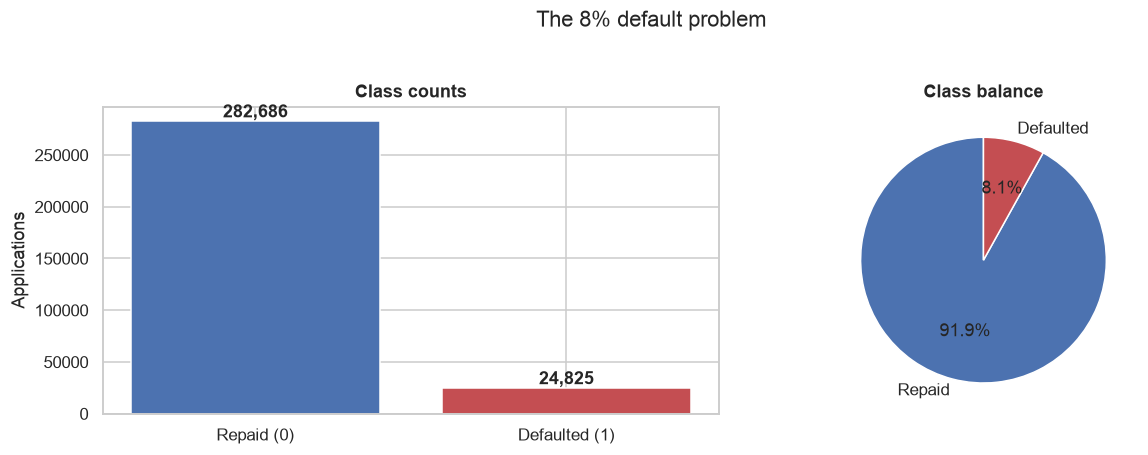

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df[TARGET].value_counts()
axes[0].bar(["Repaid (0)", "Defaulted (1)"], counts.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")
axes[0].set_title("Class counts")
axes[0].set_ylabel("Applications")

vals = df[TARGET].value_counts(normalize=True).values
axes[1].pie(vals, labels=["Repaid", "Defaulted"], autopct="%1.1f%%",
            colors=["#4C72B0", "#C44E52"], startangle=90)
axes[1].set_title("Class balance")

plt.suptitle("The 8% default problem", y=1.03)
plt.tight_layout()
plt.show()

**Why this matters:** a model that predicts "everyone repays" is 92% accurate and
completely useless. This is why we evaluate with ROC AUC and *business metrics at
the deployment threshold*, never accuracy alone.

### The single most predictive signal: external bureau scores

`EXT_SOURCE_1/2/3` are normalized scores from external credit bureaus. The
product form collects one score; training aggregates the three into
`EXT_SOURCE_MEAN` (mean of available values).

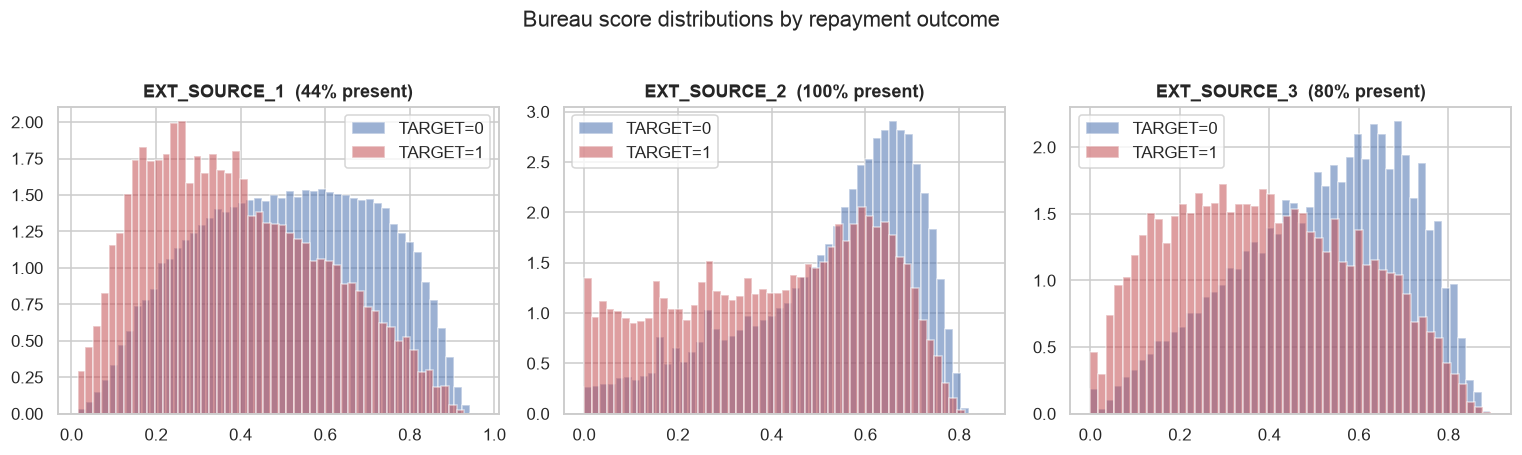

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
for ax, col in zip(axes, ext_cols):
    for target, color in [(0, "#4C72B0"), (1, "#C44E52")]:
        subset = df.loc[df[TARGET] == target, col].dropna()
        ax.hist(subset, bins=50, alpha=0.55, density=True, color=color,
                label=f"TARGET={target}")
    ax.set_title(f"{col}  ({df[col].notna().mean():.0%} present)")
    ax.legend()

plt.suptitle("Bureau score distributions by repayment outcome", y=1.03)
plt.tight_layout()
plt.show()

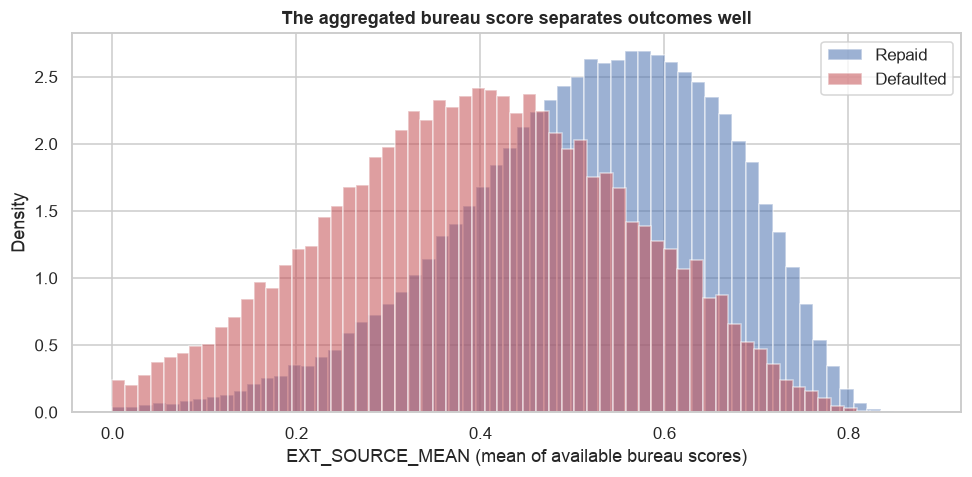

In [5]:
# The aggregate feature the model actually uses
ext_mean = df[ext_cols].mean(axis=1)

fig, ax = plt.subplots(figsize=(9, 4.5))
for target, color, label in [(0, "#4C72B0", "Repaid"), (1, "#C44E52", "Defaulted")]:
    ax.hist(ext_mean[df[TARGET] == target], bins=60, alpha=0.55, density=True,
            color=color, label=label)
ax.set_xlabel("EXT_SOURCE_MEAN (mean of available bureau scores)")
ax.set_ylabel("Density")
ax.set_title("The aggregated bureau score separates outcomes well")
ax.legend()
plt.tight_layout()
plt.show()

### Financial strain: the engineered ratios

The three ratios (`CREDIT_INCOME_PERCENT`, `ANNUITY_INCOME_PERCENT`, `CREDIT_TERM`)
are computed by **the same function at training and serving time** (`src/features.py`).

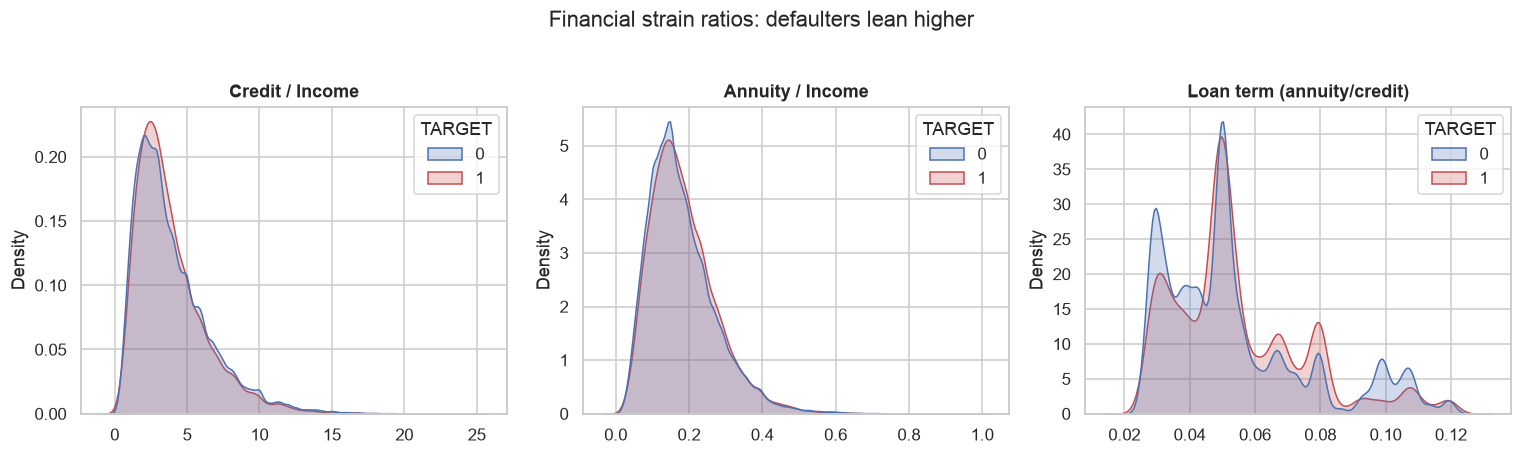

In [6]:
ratios = pd.DataFrame({
    "Credit / Income": df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"],
    "Annuity / Income": df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"],
    "Loan term (annuity/credit)": df["AMT_ANNUITY"] / df["AMT_CREDIT"],
    "TARGET": df[TARGET],
})
# Clip extreme income outliers for readable plots
plot_df = ratios[(ratios["Credit / Income"] < 25) & (ratios["Annuity / Income"] < 1)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ratios.columns[:3]):
    sns.kdeplot(data=plot_df, x=col, hue="TARGET", common_norm=False,
                fill=True, palette=["#4C72B0", "#C44E52"], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Financial strain ratios: defaulters lean higher", y=1.03)
plt.tight_layout()
plt.show()

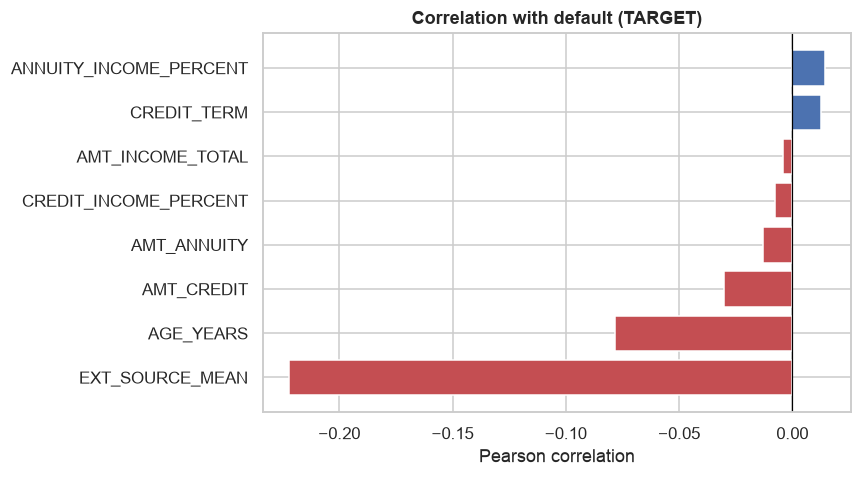

In [7]:
# Correlation of the eight serving features with default
feats = pd.DataFrame({
    "AMT_INCOME_TOTAL": df["AMT_INCOME_TOTAL"],
    "AMT_CREDIT": df["AMT_CREDIT"],
    "AMT_ANNUITY": df["AMT_ANNUITY"],
    "AGE_YEARS": -df["DAYS_BIRTH"] / 365,
    "CREDIT_INCOME_PERCENT": df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"],
    "ANNUITY_INCOME_PERCENT": df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"],
    "CREDIT_TERM": df["AMT_ANNUITY"] / df["AMT_CREDIT"],
    "EXT_SOURCE_MEAN": ext_mean,
})
corr = feats.assign(TARGET=df[TARGET]).corr()["TARGET"].drop("TARGET").sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Correlation with default (TARGET)")
ax.set_xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

## 2. The imbalance fix: SMOTE

Training uses **SMOTE** (Synthetic Minority Over-sampling Technique): instead of
duplicating default rows, it interpolates *synthetic* defaults between real
neighbors so the tree sees a balanced world. Crucially, the test set is **never**
resampled — evaluation stays honest.

In [8]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- mirrors the production split in scripts/train.py (fit / calib / test) ---
X = feats.rename(columns={"AGE_YEARS": "DAYS_BIRTH"})
X["DAYS_BIRTH"] = -X["DAYS_BIRTH"] * 365  # back to the raw unit used in training
X = X.fillna(X.median())
y = df[TARGET].astype(int)

X_fit, X_calib, y_fit, y_calib = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_fit, X_test, y_fit, y_test = train_test_split(
    X_fit, y_fit, test_size=0.235, random_state=42, stratify=y_fit)

scaler = StandardScaler().fit(X_fit)
X_fit_s = pd.DataFrame(scaler.transform(X_fit), columns=X_fit.columns)

print(f"Fit: {len(X_fit):,} | Calib: {len(X_calib):,} | Test: {len(X_test):,}")

Fit: 199,958 | Calib: 46,127 | Test: 61,426


SMOTE: (199958, 8) -> (367632, 8)  (defaults synthesised to parity)


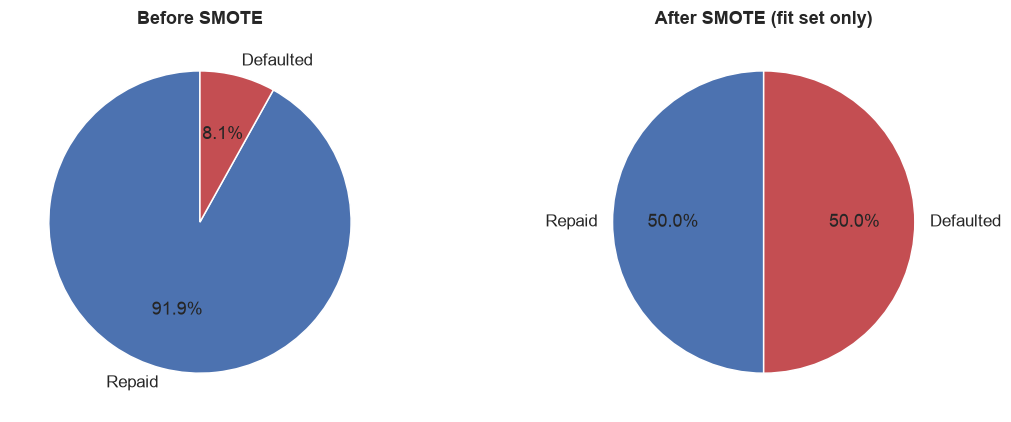

In [9]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_fit_s, y_fit)
print(f"SMOTE: {X_fit_s.shape} -> {X_res.shape}  (defaults synthesised to parity)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].pie(y_fit.value_counts().values, labels=["Repaid", "Defaulted"],
            autopct="%1.1f%%", colors=["#4C72B0", "#C44E52"], startangle=90)
axes[0].set_title("Before SMOTE")
axes[1].pie(y_res.value_counts().values, labels=["Repaid", "Defaulted"],
            autopct="%1.1f%%", colors=["#4C72B0", "#C44E52"], startangle=90)
axes[1].set_title("After SMOTE (fit set only)")
plt.tight_layout()
plt.show()

## 3. The model: XGBoost gradient-boosted trees

100 sequential trees, max depth 5. Each tree fits the **residual errors** of the
ensemble so far. Here we retrain a demo model (identical settings to production)
and look at what it learned.

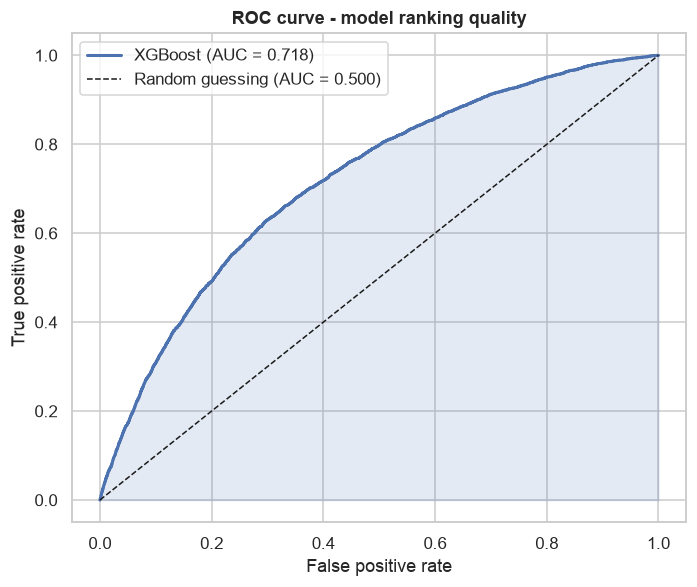

In [10]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                      eval_metric="logloss", random_state=42, n_jobs=-1)
model.fit(X_res, y_res)

# ROC curve on the untouched test set
from sklearn.metrics import roc_auc_score, roc_curve

proba_test = model.predict_proba(pd.DataFrame(scaler.transform(X_test),
                                              columns=X_test.columns))[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba_test)
auc = roc_auc_score(y_test, proba_test)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(fpr, tpr, color="#4C72B0", lw=2, label=f"XGBoost (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random guessing (AUC = 0.500)")
ax.fill_between(fpr, tpr, alpha=0.15, color="#4C72B0")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve - model ranking quality")
ax.legend()
plt.tight_layout()
plt.show()

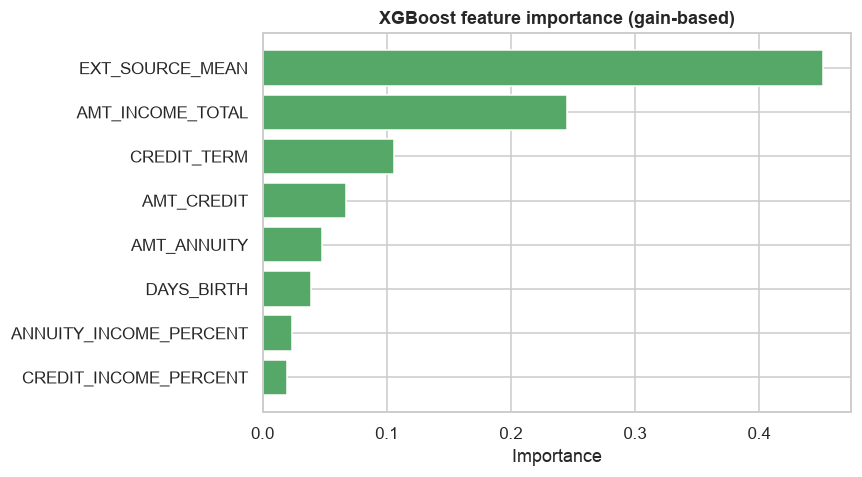

In [11]:
importances = pd.Series(model.feature_importances_, index=X_fit.columns)
importances = importances.sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(importances.index, importances.values, color="#55A868")
ax.set_title("XGBoost feature importance (gain-based)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

### The decision threshold: a *calibrated* business input

XGBoost outputs a raw probability, but the business needs a **review queue of a
known size**. Training therefore holds out a *calibration split* and picks the
cutoff that flags the riskiest 25% of applicants. The API serves that number from
`metrics.json` — no magic constants.

In [12]:
# Choose the threshold on the calibration split (out-of-sample)
proba_calib = model.predict_proba(pd.DataFrame(scaler.transform(X_calib),
                                               columns=X_calib.columns))[:, 1]
threshold = float(np.quantile(proba_calib, 1 - 0.25))
print(f"Calibrated threshold: {threshold:.3f}  (flags ~25% of applicants)")

flagged = proba_test > threshold
recall_at_thr = (flagged & (y_test == 1)).sum() / (y_test == 1).sum()
print(f"On test: flags {flagged.mean():.1%} of applicants, catches {recall_at_thr:.1%} of defaults")

Calibrated threshold: 0.482  (flags ~25% of applicants)
On test: flags 24.9% of applicants, catches 53.1% of defaults


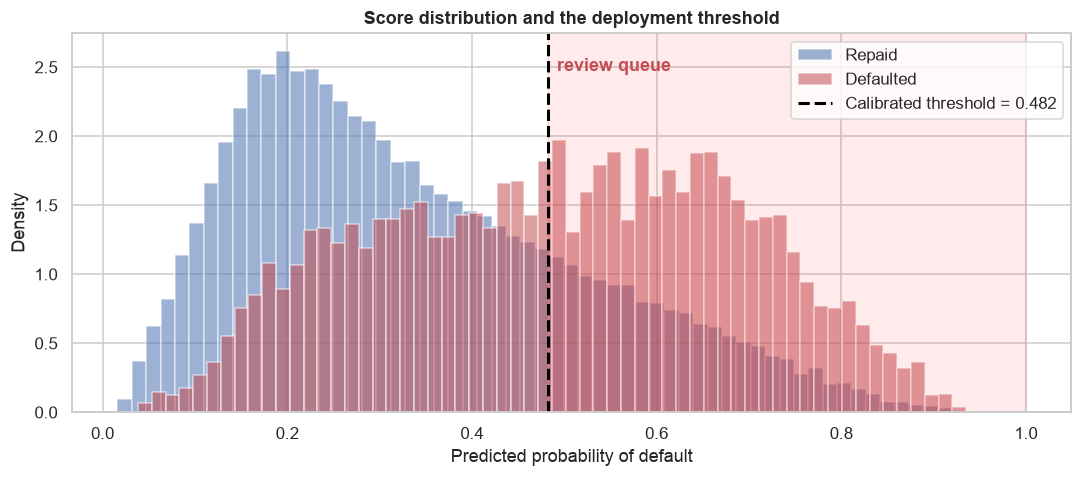

In [13]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for target, color, label in [(0, "#4C72B0", "Repaid"), (1, "#C44E52", "Defaulted")]:
    ax.hist(proba_test[y_test.values == target], bins=60, alpha=0.55,
            density=True, color=color, label=label)
ax.axvline(threshold, color="black", ls="--", lw=2,
           label=f"Calibrated threshold = {threshold:.3f}")
ax.axvspan(threshold, 1, alpha=0.08, color="red")
ax.text(threshold + 0.01, ax.get_ylim()[1] * 0.9, "review queue",
        color="#C44E52", fontweight="bold")
ax.set_xlabel("Predicted probability of default")
ax.set_ylabel("Density")
ax.set_title("Score distribution and the deployment threshold")
ax.legend()
plt.tight_layout()
plt.show()

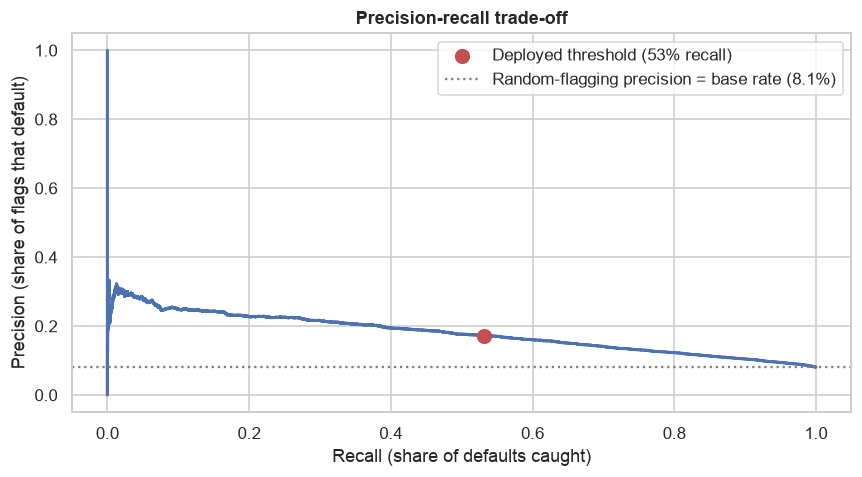

In [14]:
# The precision-recall trade-off across every possible threshold
from sklearn.metrics import precision_recall_curve

precision, recall, thr = precision_recall_curve(y_test, proba_test)
base_rate = y_test.mean()
recall_at_thr = (flagged & (y_test == 1)).sum() / (y_test == 1).sum()
precision_at_thr = (flagged & (y_test == 1)).sum() / flagged.sum()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(recall, precision, color="#4C72B0", lw=2)
ax.scatter([recall_at_thr], [precision_at_thr], color="#C44E52", zorder=5, s=80,
           label=f"Deployed threshold ({recall_at_thr:.0%} recall)")
ax.axhline(base_rate, color="gray", ls=":", lw=1.5,
           label=f"Random-flagging precision = base rate ({base_rate:.1%})")
ax.set_xlabel("Recall (share of defaults caught)")
ax.set_ylabel("Precision (share of flags that default)")
ax.set_title("Precision-recall trade-off")
ax.legend()
plt.tight_layout()
plt.show()

## 4. The backend: a live demo of the FastAPI service

Everything above happens offline. Now we hit the **actual running API container**
with the same JSON the Streamlit dashboard sends. This is the exact production
path: `dashboard -> POST /predict -> pydantic validation -> feature engineering
-> scaler -> XGBoost -> threshold -> risk decision`.

In [15]:
BASE = "http://localhost"
print("health:   ", requests.get(f"{BASE}/health", timeout=5).json())
info = requests.get(f"{BASE}/model-info", timeout=5).json()
print("model:    ", info["model_version"], "| trained:", info["trained_at"][:19])
print("metrics:  ", {k: round(v, 3) if isinstance(v, float) else v
                    for k, v in info["metrics"].items()})
print("threshold served by the API:", round(info["risk_threshold"], 3))

health:    {'status': 'ok'}
model:     1.1.0 | trained: 2026-09-24T22:57:09
metrics:   {'roc_auc': 0.721, 'accuracy': 0.767, 'recall': 0.518, 'precision': 0.178, 'threshold': 0.489, 'target_flag_rate': 0.25, 'flag_rate': 0.248, 'flagged_recall': 0.535, 'flagged_precision': 0.174}
threshold served by the API: 0.489


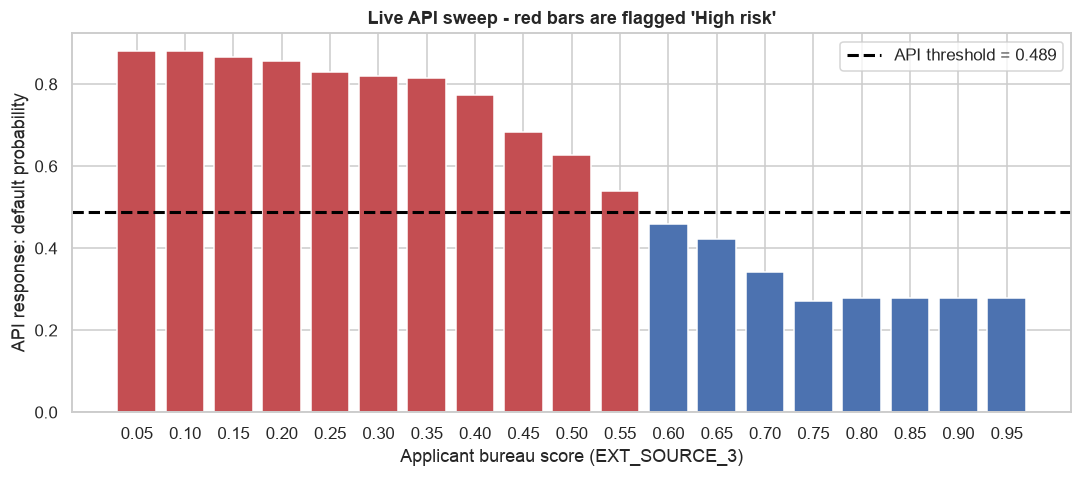

In [16]:
# The same applicant, swept across bureau scores: watch the risk decision flip
def score(income, credit, annuity, age, gender, ext_score):
    payload = {
        "AMT_INCOME_TOTAL": income, "AMT_CREDIT": credit, "AMT_ANNUITY": annuity,
        "DAYS_BIRTH": -int(age) * 365, "CODE_GENDER": gender, "EXT_SOURCE_3": ext_score,
    }
    r = requests.post(f"{BASE}/predict", json=payload, timeout=10)
    r.raise_for_status()
    return r.json()

scores = np.linspace(0.05, 0.95, 19)
probs, risks = [], []
for s in scores:
    out = score(60000, 450000, 30000, 26, "F", s)
    probs.append(out["default_probability"])
    risks.append(out["risk_level"])

api_threshold = info["risk_threshold"]
colors = ["#C44E52" if r == "High" else "#4C72B0" for r in risks]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar([f"{s:.2f}" for s in scores], probs, color=colors)
ax.axhline(api_threshold, color="black", ls="--", lw=2,
           label=f"API threshold = {api_threshold:.3f}")
ax.set_xlabel("Applicant bureau score (EXT_SOURCE_3)")
ax.set_ylabel("API response: default probability")
ax.set_title("Live API sweep - red bars are flagged 'High risk'")
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# Two applicants through the production endpoint
profiles = {
    "High risk (weak score, high leverage)": dict(income=60000, credit=450000, annuity=30000, age=26, gender="F", ext_score=0.10),
    "Low risk (strong score, low leverage)": dict(income=180000, credit=120000, annuity=9000, age=41, gender="M", ext_score=0.85),
}
rows = []
for name, kw in profiles.items():
    out = score(**kw)
    rows.append({"profile": name, "P(default)": round(out["default_probability"], 3),
                 "risk": out["risk_level"]})
display(pd.DataFrame(rows))

# And the validation layer doing its job
bad = dict(income=-5, credit=450000, annuity=30000, age=26, gender="F", ext_score=0.5)
r = requests.post(f"{BASE}/predict", json={
    "AMT_INCOME_TOTAL": bad["income"], "AMT_CREDIT": bad["credit"],
    "AMT_ANNUITY": bad["annuity"], "DAYS_BIRTH": -bad["age"] * 365,
    "CODE_GENDER": bad["gender"], "EXT_SOURCE_3": bad["ext_score"]}, timeout=10)
print(f"Negative income -> HTTP {r.status_code} (422 = rejected by pydantic, never reached the model)")

,profile,P(default),risk
0,"High risk (weak score, high leverage)",0.880,High
1,"Low risk (strong score, low leverage)",0.149,Low


Negative income -> HTTP 422 (422 = rejected by pydantic, never reached the model)


## 5. Recap

| Layer | What it does | Where to look |
|---|---|---|
| Data | 307k applications, 8% defaults, bureau scores are king | `scripts/train.py` |
| Features | 8 applicant-facing features, identical code at train & serve | `src/features.py` |
| Model | SMOTE + XGBoost, threshold calibrated on a held-out split | `scripts/train.py` |
| Serving | FastAPI validates → features → scaler → predict → threshold | `src/app.py`, `src/model.py` |
| UI | Streamlit form → JSON → verdict card | `src/dashboard.py` |
| Ops | Healthchecks, metrics endpoint, Docker compose, CI | `docker-compose.yml`, `.github/` |

**Run the stack:** `docker compose up --build` → dashboard at `localhost:8501`,
interactive API docs at `localhost/docs`.